# Nyquist Klausur-Notebook

Kurzfassung für schnelle Berechnungen.

Wichtig:
- Formel: $Z = N + P$
- stabil genau dann, wenn $Z=0$
- $P$: offene RHP-Pole von $L(s)$
- $N$: Umlaeufe um den Punkt $-1$

Dieses Notebook ist auf Rechnen ausgelegt, nicht auf lange Theorie.

## 1. Setup (einmal ausfuehren)

Diese Zellen laden Funktionen und Hilfsroutinen.

## 2. On-the-go Berechnung (Klausur)

In der naechsten Codezelle entweder `funktion` oder `num`, `den`, `w_min`, `w_max`, `punkte` anpassen.

Ausgabe:
- Stabilitaetsentscheidung
- Nyquist-Plot
- Kontrollrechnung ueber geschlossene Pole

In [70]:
import importlib
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

projekt_root = Path.cwd()
if not (projekt_root / 'regelungstechnik').exists():
    projekt_root = projekt_root.parent
if str(projekt_root) not in sys.path:
    sys.path.insert(0, str(projekt_root))

import regelungstechnik.stabilitaet as stabilitaet_mod
stabilitaet_mod = importlib.reload(stabilitaet_mod)
nyquist_kriterium = stabilitaet_mod.nyquist_kriterium
parse_uebertragungsfunktion = stabilitaet_mod.parse_uebertragungsfunktion

plt.rcParams['figure.figsize'] = (7, 7)
plt.rcParams['axes.grid'] = True

In [71]:
def poles_of(den):
    '''Pole der Übertragungsfunktion = Nullstellen des Nennerpolynoms.'''
    return np.roots(den)

def rhp_pole_count(den, tol=1e-9):
    '''Anzahl der Pole in der offenen rechten s-Halbebene, Re(s) > 0.'''
    p = poles_of(den)
    return int(np.sum(np.real(p) > tol))

def axis_pole_freqs(den, tol=1e-6):
    '''
    Liefert die (nichtnegativen) Frequenzen omega >= 0 der Pole, die auf der
    imaginaeren Achse liegen (Re(s) ~ 0), z.B. omega=0 fuer einen Integrator.
    Wird gebraucht, um den Nyquist-Weg an diesen Stellen einzuindentieren.
    '''
    p = poles_of(den)
    axis = p[np.abs(np.real(p)) < tol]
    freqs = np.imag(axis)
    freqs = freqs[freqs >= -tol]
    freqs = sorted(set(0.0 if abs(f) < tol else round(float(f), 8) for f in freqs))
    return freqs

def eval_L(num, den, s):
    '''Wertet L(s) = num(s)/den(s) punktweise (auch fuer komplexe Arrays s) aus.'''
    return np.polyval(num, s) / np.polyval(den, s)


In [72]:
def count_encirclements(L_values, point=-1 + 0j):
    '''
    Beibehalten fuer Tabellen-/Kontrollrechnungen.
    '''
    rel = np.asarray(L_values) - point
    angles = np.unwrap(np.angle(rel))
    total_change = angles[-1] - angles[0]
    return -total_change / (2 * np.pi)


def closed_loop_den(num, den):
    '''
    Nennerpolynom des geschlossenen Kreises bei Einheitsrueckfuehrung: den(s)+num(s).
    '''
    den = np.asarray(den, dtype=float)
    num = np.asarray(num, dtype=float)
    num_padded = np.zeros_like(den)
    num_padded[-len(num):] = num
    return den + num_padded


def plot_nyquist(num, den, title="Nyquist-Ortskurve", ax=None, mark_omegas=None, **kwargs):
    '''
    Zeichnet die Nyquist-Ortskurve direkt mit Matplotlib und markiert optional
    Stuetzstellen fuer ausgewaehlte omega.
    Rueckgabe bleibt kompatibel: (N, ax).
    N ist hier die Uhrzeigersinn-Umlaufzahl, damit Z = N + P gilt.
    '''
    w_min = float(kwargs.get('w_min', 1e-3))
    w_max = float(kwargs.get('w_max', 1e3))
    punkte = int(kwargs.get('punkte', 3000))

    analyse = nyquist_kriterium(num, den, w_min=w_min, w_max=w_max, punkte=punkte)
    ws = np.logspace(np.log10(w_min), np.log10(w_max), punkte)
    L_pos = eval_L(num, den, 1j * ws)
    L_neg = np.conjugate(L_pos[::-1])

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(L_pos.real, L_pos.imag, color='C0', lw=2, label='Nyquist')
    ax.plot(L_neg.real, L_neg.imag, color='C0', lw=2)
    ax.axhline(0, color='gray', lw=1)
    ax.axvline(0, color='gray', lw=1)
    ax.scatter([-1], [0], marker='x', s=70, color='red', label='kritischer Punkt -1')

    # Richtungspfeil auf positiver Frequenzhaelfte
    k = max(5, len(ws) // 3)
    ax.annotate(
        '',
        xy=(L_pos.real[k + 1], L_pos.imag[k + 1]),
        xytext=(L_pos.real[k], L_pos.imag[k]),
        arrowprops=dict(arrowstyle='->', color='C0', lw=1.5),
    )

    if mark_omegas is not None and len(mark_omegas) > 0:
        mark_omegas = np.asarray(mark_omegas, dtype=float)
        Lm = eval_L(num, den, 1j * mark_omegas)
        ok = np.isfinite(np.real(Lm)) & np.isfinite(np.imag(Lm))
        if np.any(ok):
            ax.scatter(np.real(Lm[ok]), np.imag(Lm[ok]), s=35, color='darkorange',
                       edgecolor='black', linewidth=0.5, zorder=5, label='Stuetzstellen')
            for w, z in zip(mark_omegas[ok], Lm[ok]):
                ax.annotate(f'ω={w:g}', (np.real(z), np.imag(z)),
                            textcoords='offset points', xytext=(5, 5), fontsize=8, color='darkorange')

    stabil_text = 'stabil' if analyse['ergebnis']['stabil'] else 'instabil'
    ax.set_title(f"{title} ({stabil_text})")
    ax.set_xlabel('Re{L(jω)}')
    ax.set_ylabel('Im{L(jω)}')
    ax.grid(True, alpha=0.35)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')

    # Klausur-Konvention: N als CW-Umlaufzahl, damit Z = N + P direkt passt.
    N = float(analyse['ergebnis']['N_cw'])

    return N, ax


def nyquist_table(num, den, omegas, show=True):
    '''
    Wertetabelle von L(jw) fuer die ueblichen Stuetzstellen.
    '''
    omegas = np.asarray(omegas, dtype=float)
    L = eval_L(num, den, 1j * omegas)
    df = pd.DataFrame({
        'ω [rad/s]': omegas,
        'Re(L(jω))': L.real,
        'Im(L(jω))': L.imag,
        '|L(jω)|': np.abs(L),
        'arg(L(jω)) [°]': np.degrees(np.angle(L)),
    }).set_index('ω [rad/s]').round(4)

    if show:
        display(df)
    return df


def imag_axis_crossings(num, den, w_min=1e-3, w_max=1e3, punkte=6000, tol=1e-9):
    '''
    Numerische Schnittpunkte der Nyquist-Kurve mit der imaginaeren Achse
    ueber Re(L(jw)) = 0 fuer omega > 0.
    '''
    ws = np.logspace(np.log10(w_min), np.log10(w_max), int(punkte))
    Ljw = eval_L(num, den, 1j * ws)
    re = np.real(Ljw)

    valid = np.isfinite(re)
    roots = []

    def f(w):
        return float(np.real(eval_L(num, den, 1j * w)))

    def bisect_root(a, b, iters=60):
        fa = f(a)
        fb = f(b)
        if not np.isfinite(fa) or not np.isfinite(fb):
            return None
        if abs(fa) < tol:
            return a
        if abs(fb) < tol:
            return b
        if fa * fb > 0:
            return None
        lo, hi = a, b
        flo = fa
        for _ in range(iters):
            mid = 0.5 * (lo + hi)
            fmid = f(mid)
            if not np.isfinite(fmid):
                return None
            if abs(fmid) < tol:
                return mid
            if flo * fmid <= 0:
                hi = mid
            else:
                lo, flo = mid, fmid
        return 0.5 * (lo + hi)

    for i in range(len(ws) - 1):
        if not (valid[i] and valid[i + 1]):
            continue
        a, b = ws[i], ws[i + 1]
        ra, rb = re[i], re[i + 1]

        if abs(ra) < tol:
            roots.append(a)
            continue
        if ra * rb < 0:
            r = bisect_root(a, b)
            if r is not None:
                roots.append(r)

    roots = sorted(roots)
    merged = []
    for w in roots:
        if not merged or abs(w - merged[-1]) / max(1.0, abs(merged[-1])) > 1e-3:
            merged.append(w)

    data = []
    for w in merged:
        val = eval_L(num, den, 1j * w)
        if np.isfinite(np.real(val)) and np.isfinite(np.imag(val)):
            data.append((w, np.real(val), np.imag(val), val))

    return pd.DataFrame(data, columns=['ω [rad/s]', 'Re(L(jω))', 'Im(L(jω))', 'L(jω)'])


def imag_axis_crossings_table(num, den, w_min=1e-3, w_max=1e3, punkte=6000, show=True):
    '''
    Formatiert die Schnittpunkte mit der imaginaeren Achse als Tabelle.
    '''
    df = imag_axis_crossings(num, den, w_min=w_min, w_max=w_max, punkte=punkte)
    if df.empty:
        print('Keine Schnitte mit der imaginaeren Achse im untersuchten Frequenzbereich gefunden.')
        return df
    df = df.set_index('ω [rad/s]').round(4)
    if show:
        display(df)
    return df


def real_axis_crossings(num, den, w_min=1e-3, w_max=1e3, punkte=6000, tol=1e-9):
    '''
    Numerische Schnittpunkte der Nyquist-Kurve mit der reellen Achse
    ueber Im(L(jw)) = 0 fuer omega > 0.
    '''
    ws = np.logspace(np.log10(w_min), np.log10(w_max), int(punkte))
    Ljw = eval_L(num, den, 1j * ws)
    im = np.imag(Ljw)

    valid = np.isfinite(im)
    roots = []

    def f(w):
        return float(np.imag(eval_L(num, den, 1j * w)))

    def bisect_root(a, b, iters=60):
        fa = f(a)
        fb = f(b)
        if not np.isfinite(fa) or not np.isfinite(fb):
            return None
        if abs(fa) < tol:
            return a
        if abs(fb) < tol:
            return b
        if fa * fb > 0:
            return None
        lo, hi = a, b
        flo = fa
        for _ in range(iters):
            mid = 0.5 * (lo + hi)
            fmid = f(mid)
            if not np.isfinite(fmid):
                return None
            if abs(fmid) < tol:
                return mid
            if flo * fmid <= 0:
                hi = mid
            else:
                lo, flo = mid, fmid
        return 0.5 * (lo + hi)

    for i in range(len(ws) - 1):
        if not (valid[i] and valid[i + 1]):
            continue
        a, b = ws[i], ws[i + 1]
        ia, ib = im[i], im[i + 1]

        if abs(ia) < tol:
            roots.append(a)
            continue
        if ia * ib < 0:
            r = bisect_root(a, b)
            if r is not None:
                roots.append(r)

    roots = sorted(roots)
    merged = []
    for w in roots:
        if not merged or abs(w - merged[-1]) / max(1.0, abs(merged[-1])) > 1e-3:
            merged.append(w)

    data = []
    for w in merged:
        val = eval_L(num, den, 1j * w)
        if np.isfinite(np.real(val)) and np.isfinite(np.imag(val)):
            data.append((w, np.real(val), np.imag(val), val))

    return pd.DataFrame(data, columns=['ω [rad/s]', 'Re(L(jω))', 'Im(L(jω))', 'L(jω)'])


def real_axis_crossings_table(num, den, w_min=1e-3, w_max=1e3, punkte=6000, show=True):
    '''
    Formatiert die Schnittpunkte mit der reellen Achse als Tabelle.
    '''
    df = real_axis_crossings(num, den, w_min=w_min, w_max=w_max, punkte=punkte)
    if df.empty:
        print('Keine Schnitte mit der reellen Achse im untersuchten Frequenzbereich gefunden.')
        return df
    df = df.set_index('ω [rad/s]').round(4)
    if show:
        display(df)
    return df

## 3. Hauptrechnung (Klausur)

Die nächste Zelle ist die Hauptzelle für schnelle Berechnungen.

EINGABE Funktion = (2.5*(1-s))/(s^2+3*s+2)
EINGABE Parameter = {'k_R': 5}
EINGABE num = [-2.5, 2.5]
EINGABE den = [1.0, 3.0, 2.0]
EINGABE Frequenzbereich = (0.01, 100.0) punkte= 4000
EINGABE Stuetzstellen ω = [ 0.1  0.3  0.7  1.   2.   5.  10. ]

AUSGABE offene Pole: [-2. -1.]
AUSGABE P = 0
AUSGABE N = 0.000 (gerundet 0)
AUSGABE Z = N + P = 0
AUSGABE Stabilitaet: STABIL
AUSGABE geschlossene Pole: [-0.25+2.10653744j -0.25-2.10653744j]
AUSGABE instabile geschlossene Pole: 0


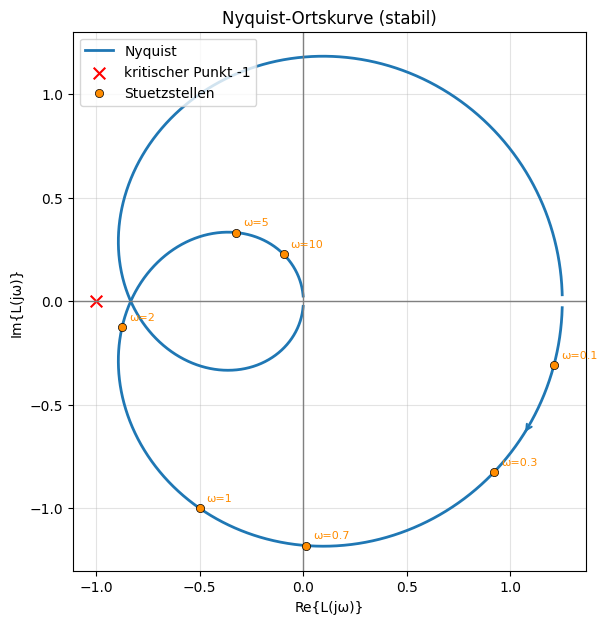

In [73]:
# EINGABE (hier anpassen)
funktion = '(2.5*(1-s))/(s^2+3*s+2)'
parameter = {'k_R': 5}
num = [5]
den = [1, 4, 5, 2]
w_min = 1e-2
w_max = 1e2
punkte = 4000

# Stuetzstellen fuer Markierungen im Nyquist-Diagramm
mark_omegas = np.array([0.1, 0.3, 0.7, 1.0, 2.0, 5.0, 10.0])

# Beispiel fuer direkte Funktionseingabe:
# funktion = 'k_R/((s+3)^2(s-1))'
# parameter = {'k_R': 5}

if funktion:
    num, den = parse_uebertragungsfunktion(funktion, substitutions=parameter)
    print("EINGABE Funktion =", funktion)
    if parameter:
        print("EINGABE Parameter =", parameter)
else:
    num, den = parse_uebertragungsfunktion(num, den, substitutions=parameter)

print("EINGABE num =", num.tolist())
print("EINGABE den =", den.tolist())
print("EINGABE Frequenzbereich =", (w_min, w_max), "punkte=", punkte)
print("EINGABE Stuetzstellen ω =", mark_omegas)

P = rhp_pole_count(den)
print("\nAUSGABE offene Pole:", poles_of(den))
print("AUSGABE P =", P)

N, ax = plot_nyquist(
    num, den,
    title="Nyquist-Ortskurve",
    w_min=w_min,
    w_max=w_max,
    punkte=punkte,
    mark_omegas=mark_omegas,
 )
Z = int(round(N) + P)
print(f"AUSGABE N = {N:.3f} (gerundet {round(N)})")
print(f"AUSGABE Z = N + P = {Z}")
print("AUSGABE Stabilitaet:", "STABIL" if Z == 0 else "INSTABIL")

poles_closed = poles_of(closed_loop_den(num, den))
print("AUSGABE geschlossene Pole:", poles_closed)
print("AUSGABE instabile geschlossene Pole:", int(np.sum(np.real(poles_closed) > 1e-6)))

In [74]:
# Stuetzstellen fuer die Wertetabelle
omegas1 = np.round(np.logspace(np.log10(w_min), np.log10(w_max), 13), 3)

print('Wertetabelle L(jω):')
table1 = nyquist_table(num, den, omegas1, show=True)

print('\nSchnitt mit der imaginaeren Achse (Re(L(jω)) = 0):')
crossings1 = imag_axis_crossings_table(num, den, w_min=w_min, w_max=w_max, punkte=8000, show=True)

print('\nSchnitt mit der reellen Achse (Im(L(jω)) = 0):')
crossings_real1 = real_axis_crossings_table(num, den, w_min=w_min, w_max=w_max, punkte=8000, show=True)

Wertetabelle L(jω):


,Re(L(jω)),Im(L(jω)),|L(jω)|,arg(L(jω)) [°]
ω [rad/s],,,,
0.010,1.2496,-0.0312,1.2500,-1.4324
0.022,1.2480,-0.0687,1.2499,-3.1508
0.046,1.2414,-0.1433,1.2497,-6.5851
0.100,1.2098,-0.3080,1.2484,-14.2836
0.215,1.0719,-0.6290,1.2428,-30.4035
0.464,0.5558,-1.0834,1.2177,-62.8442
1.000,-0.5000,-1.0000,1.1180,-116.5651
2.154,-0.8496,-0.0398,0.8505,-177.3167
4.642,-0.3654,0.3334,0.4946,137.6230



Schnitt mit der imaginaeren Achse (Re(L(jω)) = 0):


,Re(L(jω)),Im(L(jω)),L(jω)
ω [rad/s],,,
0.707107,-0.0,-1.1785,-0.0000-1.1785j



Schnitt mit der reellen Achse (Im(L(jω)) = 0):


,Re(L(jω)),Im(L(jω)),L(jω)
ω [rad/s],,,
2.236068,-0.8333,0.0,-0.8333+0.0000j


## 4. Optionales Zusatzbeispiel

Nur verwenden, wenn du ein zweites Beispiel zum Gegencheck brauchst.

Pole von L2(s): [-5.  1.]
P (instabile Pole des offenen Kreises) = 1
N (Umlaeufe um -1) = -1.000  ->  gerundet -1
Z = N + P = 0  ->  geschlossener Kreis ist STABIL
Pole des geschlossenen Kreises: [-8.40512484 -0.59487516]
Tatsaechliche Anzahl instabiler Pole (RHE): 0


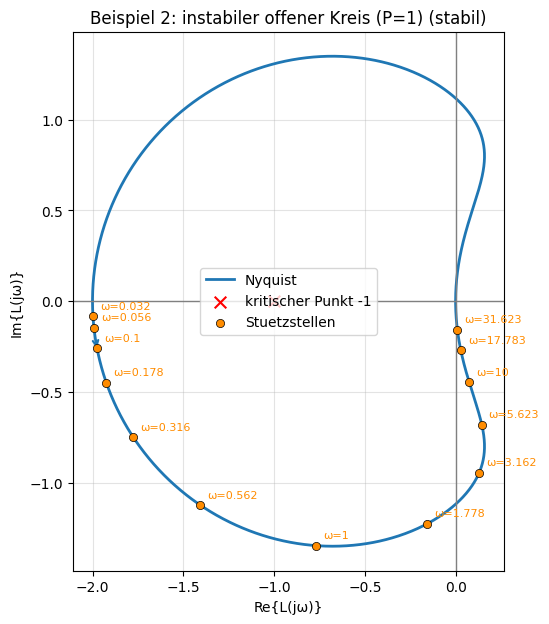

In [75]:
num2, den2 = [5, 10], [1, 4, -5]   # 5(s+2) / [(s-1)(s+5)] = 5(s+2)/(s^2+4s-5)
print("Pole von L2(s):", poles_of(den2))

P2 = rhp_pole_count(den2)
print(f"P (instabile Pole des offenen Kreises) = {P2}")

omegas2 = np.round(np.logspace(-1.5, 1.5, 13), 3)

N2, ax = plot_nyquist(num2, den2, mark_omegas=omegas2, title="Beispiel 2: instabiler offener Kreis (P=1)")
Z2 = round(N2) + P2
print(f"N (Umlaeufe um -1) = {N2:.3f}  ->  gerundet {round(N2)}")
print(f"Z = N + P = {Z2}  ->  geschlossener Kreis ist {'STABIL' if Z2 == 0 else 'INSTABIL'}")

poles_closed2 = poles_of(closed_loop_den(num2, den2))
print("Pole des geschlossenen Kreises:", poles_closed2)
print("Tatsaechliche Anzahl instabiler Pole (RHE):", int(np.sum(np.real(poles_closed2) > 1e-6)))


In [76]:
nyquist_table(num2, den2, omegas2)   # exakt die Stuetzstellen, die oben im Plot markiert sind


,Re(L(jω)),Im(L(jω)),|L(jω)|,arg(L(jω)) [°]
ω [rad/s],,,,
0.032,-1.9975,-0.0831,1.9992,-177.6172
0.056,-1.9922,-0.1452,1.9975,-175.8326
0.100,-1.9754,-0.2575,1.9922,-172.5728
0.178,-1.9239,-0.4491,1.9756,-166.8600
0.316,-1.7750,-0.7498,1.9269,-157.1012
0.562,-1.4062,-1.1233,1.7997,-141.3818
1.000,-0.7692,-1.3462,1.5504,-119.7449
1.778,-0.1569,-1.2260,1.2360,-97.2930
3.162,0.1299,-0.9446,0.9535,-82.1729


,Re(L(jω)),Im(L(jω)),|L(jω)|,arg(L(jω)) [°]
ω [rad/s],,,,
0.032,-1.9975,-0.0831,1.9992,-177.6172
0.056,-1.9922,-0.1452,1.9975,-175.8326
0.100,-1.9754,-0.2575,1.9922,-172.5728
0.178,-1.9239,-0.4491,1.9756,-166.8600
0.316,-1.7750,-0.7498,1.9269,-157.1012
0.562,-1.4062,-1.1233,1.7997,-141.3818
1.000,-0.7692,-1.3462,1.5504,-119.7449
1.778,-0.1569,-1.2260,1.2360,-97.2930
3.162,0.1299,-0.9446,0.9535,-82.1729
